# A grid-forming microgrid: droop control and fault ride-through

The energy transition is replacing spinning iron with silicon. Synchronous
generators — the giant rotating machines whose physical inertia has kept grid
frequency steady for a century — are giving way to **inverter-interfaced**
sources: solar, wind, batteries. An inverter has no inertia of its own, so the
grid's stability now lives in *control software*. A **grid-forming inverter**
is one that behaves like a voltage source behind an impedance and actively sets
the local voltage and frequency, the way a generator used to. The dominant way
to make several of them cooperate without a communication link is **droop
control**: each inverter lowers its frequency in proportion to the active power
it delivers, and lowers its voltage in proportion to the reactive power — so the
shared frequency becomes a global signal that automatically balances generation
against load.

This notebook builds a small droop-controlled microgrid in Jaxonomy and puts it
through the test that matters in practice: a **fault**. We step the load up, we
trip a source offline, and we watch the surviving inverters *ride through* —
frequency dips and recovers, the load is picked up, voltage sags and restores.

**By the end you will be able to:**

1. Write the droop + swing-equation reduction of a grid-forming inverter as a
   Jaxonomy `LeafSystem`, with a lossless power-flow network coupling the buses.
2. Show **proportional power sharing** — set by the droop coefficients alone,
   with no communication between inverters — and verify it against the droop
   ratio quantitatively.
3. Predict and confirm the post-disturbance steady-state frequency from the
   droop law $\Delta f = -m_{\mathrm{eq}}\,\Delta P$, and check active-power
   balance through a load step.
4. Demonstrate **fault ride-through**: a load step and a source trip, with the
   microgrid re-balancing to a new stable operating point instead of diverging.

**Reading time:** ~25 minutes. **Runtime:** ~1 minute on a laptop CPU (float64).

> **Out of scope, on purpose.** This is an *averaged, reduced* power-systems
> model — the standard droop + swing + lossless-power-flow reduction used for
> microgrid stability and sharing studies (Chandorkar–Divan; Kundur; Guerrero).
> It is **not** a switched-PWM electromagnetic-transient (EMT) simulation, it is
> **not** full three-phase, and it does not resolve the inner current/voltage
> control loops or the LCL filter. Renewable variability here is a
> *deterministic* time profile, not a stochastic process — Jaxonomy has no SDE
> solver, so we are honest about that rather than faking randomness. The reduced
> model is exactly the right altitude for power sharing and fault ride-through;
> a higher-fidelity RLC variant could be built with Jaxonomy's acausal
> electrical library, but that is a different notebook.


## Prerequisites

Self-contained. Familiarity helps:
- [Creating custom blocks](../tutorials/02-creating-custom-blocks.ipynb) — the `LeafSystem` API we use to write the microgrid model.

No installs beyond Jaxonomy.

In [1]:
# Standard scientific Python
from __future__ import annotations
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# JAX with float64 -- the power balance and the mHz-level droop offsets need it.
from jax import config as _jax_config
_jax_config.update("jax_enable_x64", True)
import jax, jax.numpy as jnp

# Jaxonomy
import jaxonomy
from jaxonomy import DiagramBuilder, LeafSystem, simulate, SimulatorOptions
from jaxonomy.framework import DependencyTicket
from jaxonomy import logging as jx_logging
jx_logging.set_log_level(jx_logging.ERROR)

RNG_SEED = 0
np.random.seed(RNG_SEED)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.3})
print(f"jaxonomy {jaxonomy.__version__} | x64 = {jax.config.jax_enable_x64}")

jaxonomy 2.2.0 | x64 = True


## 1 · The droop + swing reduction

A grid-forming inverter, averaged over its switching period, behaves like a
controllable AC voltage source: a voltage of magnitude $V_i$ at phase angle
$\delta_i$, connected to the rest of the grid through a (mostly inductive) line
reactance. The control law that lets many of them share a load without talking
to each other is **droop**, the direct analogue of a synchronous generator's
governor and exciter:

$$
\omega_i^{*} = \omega_0 - m_i\,(P_i - P_{\mathrm{set},i}), \qquad
V_i = V_0 - n_i\,(Q_i - Q_{\mathrm{set},i}). \tag{1}
$$

The first law is the heart of it: an inverter delivering more active power $P_i$
*lowers its frequency*. Because all inverters synchronise to one common
frequency at steady state, that shared frequency is a global broadcast of the
supply/demand balance — and the inverter with the **smaller** droop coefficient
$m_i$ (a "stiffer" source) ends up carrying **more** of the load. The second law
does the same for reactive power $Q_i$ and voltage.

The angle is a state, driven by the difference between the droop-commanded
frequency and a common reference $\omega_{\mathrm{com}}$ (we take
$\omega_{\mathrm{com}}=\omega_0$, i.e. we work in a frame rotating at nominal):

$$
\dot\delta_i = \omega_i^{*} - \omega_{\mathrm{com}}
            = -\,m_i\,(P_i - P_{\mathrm{set},i}). \tag{2}
$$

This is the **swing-equation reduction**: where a generator has rotor inertia
$M\ddot\delta = P_m - P_e$, the droop inverter has the first-order law (2) — the
droop gain $m_i$ plays the role the damping/governor term plays in the swing
equation, and the *measurement filter* below supplies the effective inertia.

**Power flow (lossless line model).** The active and reactive power inverter $i$
injects toward the load bus (angle $\delta_L$, voltage $V_L$) across reactance
$X$ is the standard lossless two-bus flow:

$$
P_i = \frac{V_i V_L}{X}\sin(\delta_i - \delta_L), \qquad
Q_i = \frac{V_i^2}{X} - \frac{V_i V_L}{X}\cos(\delta_i - \delta_L). \tag{3}
$$

**Measurement filter.** Real droop controllers never feed the *instantaneous*
power into (1) — they low-pass it first (the same averaging that lets us drop the
switching). Each filtered power is an extra state with time constant $\tau$:

$$
\dot P_{f,i} = \frac{P_i - P_{f,i}}{\tau}, \qquad
\dot Q_{f,i} = \frac{Q_i - Q_{f,i}}{\tau}, \tag{4}
$$

and it is $P_{f,i}, Q_{f,i}$ (not the raw $P_i, Q_i$) that enter the droop laws
(1)–(2). This filter is what gives the otherwise inertia-less inverter its
dynamic response — the frequency *dips and recovers* rather than jumping.

**Load bus.** The load bus carries no source, so its angle $\delta_L$ is fixed
by the requirement that injected power equals the load. Rather than solve a DAE,
we let $\delta_L$ relax on a fast time constant $\tau_L \ll \tau$ toward the
power-balancing angle — a numerically robust singular-perturbation stand-in for
the algebraic constraint $\sum_i P_i = P_L$:

$$
\dot\delta_L = \frac{1}{\tau_L}\Big(\textstyle\sum_i P_i - P_L\Big). \tag{5}
$$

So the full state vector is $[\,\delta_i,\ P_{f,i},\ Q_{f,i}\,]_{i=1}^{N}$ plus
the single load-bus angle $\delta_L$. We model $N=2$ (and later $N=3$)
grid-forming inverters feeding one load bus.

In [2]:
# Per-unit, 50 Hz system.
F0    = 50.0
W0    = 2.0 * np.pi * F0     # nominal angular frequency [rad/s]
V0    = 1.0                  # nominal voltage [pu]
TAU   = 0.05                 # power-measurement filter time constant [s]
X_LINE = 0.5                # inverter -> load line reactance [pu]
TAU_L = 5.0e-4              # load-bus relaxation time constant [s] (fast)

print(f"system: {F0} Hz, V0={V0} pu, filter tau={TAU*1e3:.0f} ms, "
      f"line X={X_LINE} pu")

system: 50.0 Hz, V0=1.0 pu, filter tau=50 ms, line X=0.5 pu


## 2 · The microgrid as a `LeafSystem`

We pack the whole network into one `LeafSystem` whose continuous state is the
vector above. Putting the network in a single block (rather than one block per
inverter wired through connection ports) keeps the lossless power-flow coupling
(3) explicit and avoids an algebraic loop between buses — the angles are states,
so every output is read from state, never fed through.

The constructor takes the droop coefficients and the load, plus three optional
**fault** arguments evaluated with `jnp.where` on the simulation time — no event
API needed, which is the simplest robust way to schedule a disturbance:

- `t_fault` — when the disturbance happens,
- `PL_post` — the load value for $t \ge t_{\text{fault}}$ (a **load step**),
- `trip_idx` — an inverter index that **disconnects** for $t \ge t_{\text{fault}}$
  (a **source trip**).

In [3]:
def build_microgrid(*, m, n, Pset, Qset, PL, QL=0.0,
                    t_fault=None, PL_post=None, trip_idx=None,
                    name="microgrid"):
    """Build a droop microgrid diagram. m, n, Pset, Qset are length-N arrays.

    m  : frequency-droop coeffs [rad/s per pu]  -> df = -(m/2pi)*dP
    n  : voltage-droop coeffs   [pu per pu]
    PL : nominal active load [pu]; PL_post applies for t >= t_fault (load step)
    trip_idx : index of an inverter that disconnects for t >= t_fault
    """
    m    = jnp.asarray(m, float);    n    = jnp.asarray(n, float)
    Pset = jnp.asarray(Pset, float); Qset = jnp.asarray(Qset, float)
    N = m.shape[0]
    PL_post = PL if PL_post is None else PL_post
    t_fault = jnp.inf if t_fault is None else t_fault

    class Microgrid(LeafSystem):
        def __init__(self, name=None, **kwargs):
            super().__init__(name=name, **kwargs)
            self.N = N
            # state = [delta_0..N-1, Pf_0..N-1, Qf_0..N-1, delta_L]
            x0 = jnp.concatenate([jnp.zeros(N), Pset, Qset, jnp.zeros(1)])
            self.declare_continuous_state(default_value=x0, ode=self._ode,
                                          requires_inputs=False)
            self.declare_output_port(
                self._out, requires_inputs=False,
                prerequisites_of_calc=[DependencyTicket.xc], name="y")

        def _voltages(self, Qf):                       # droop law (1), V part
            return V0 - n * (Qf - Qset)

        def _flows(self, time, x):
            N = self.N
            delta, Pf, Qf = x[:N], x[N:2*N], x[2*N:3*N]
            dL = x[3*N]
            V  = self._voltages(Qf)
            # source trip: availability mask via jnp.where on time
            if trip_idx is None:
                avail = jnp.ones(N)
            else:
                avail = jnp.where(time >= t_fault,
                                  jnp.ones(N).at[trip_idx].set(0.0),
                                  jnp.ones(N))
            VL  = V0
            ang = delta - dL
            Pinj = avail * (V * VL / X_LINE) * jnp.sin(ang)            # eq (3) P
            Qinj = avail * (V*V/X_LINE - V*VL/X_LINE * jnp.cos(ang))   # eq (3) Q
            return delta, Pf, Qf, dL, V, avail, Pinj, Qinj

        def _ode(self, time, state, **params):
            N = self.N
            x = state.continuous_state
            delta, Pf, Qf, dL, V, avail, Pinj, Qinj = self._flows(time, x)
            PLt = jnp.where(time >= t_fault, PL_post, PL)     # load step, eq sched
            ddelta = -m * (Pf - Pset) * avail                # eq (2); trip freezes
            dPf = (Pinj - Pf) / TAU                           # eq (4)
            dQf = (Qinj - Qf) / TAU
            ddL = (jnp.sum(Pinj) - PLt) / TAU_L              # eq (5)
            return jnp.concatenate([ddelta, dPf, dQf, jnp.atleast_1d(ddL)])

        def _out(self, time, state, **params):
            return state.continuous_state

    builder = DiagramBuilder()
    sys = builder.add(Microgrid(name="mg"))
    diagram = builder.build(name=name)
    ctx = diagram.create_context()
    return diagram, ctx, sys


def run(diagram, ctx, sys, t1, max_step=0.01):
    res = simulate(
        diagram, ctx, (0.0, t1),
        options=SimulatorOptions(rtol=1e-8, atol=1e-10,
                                 max_major_step_length=max_step,
                                 buffer_length=200_000),
        recorded_signals={"y": sys.output_ports[0]})
    return res


def decode(res, N):
    Y = np.asarray(res.outputs["y"]); t = np.asarray(res.time)
    return t, Y[:, :N], Y[:, N:2*N], Y[:, 2*N:3*N], Y[:, 3*N]  # t,delta,Pf,Qf,dL


def freq_hz(Pf, m, Pset):
    """Local droop frequency f_i = (W0 - m_i*(Pf_i - Pset_i)) / 2pi."""
    return (W0 - np.asarray(m) * (Pf - np.asarray(Pset))) / (2*np.pi)

print("model + helpers defined")

model + helpers defined


## 3 · Proportional power sharing, no communication

Two identical inverters ($m_1=m_2$) share a $P_L=0.8$ pu load. Droop control
should split it **50/50** and pull both to one common frequency. Then we make
inverter 1 "stiffer" ($m_2 = m_1/2$) and expect **2:1** sharing — the stiffer
unit carries twice as much — at a (different) common frequency. None of this
requires a communication link: the shared frequency does the coordinating.

In [4]:
# --- equal droop -> 50/50 ---
m_eq  = np.array([2.0, 2.0])      # rad/s per pu
n_eq  = np.array([0.1, 0.1])
zero2 = np.array([0.0, 0.0])
PL    = 0.8

d, c, s = build_microgrid(m=m_eq, n=n_eq, Pset=zero2, Qset=zero2, PL=PL)
res_eq  = run(d, c, s, t1=6.0)
t_eq, dlt_eq, Pf_eq, Qf_eq, dL_eq = decode(res_eq, 2)
f_eq = freq_hz(Pf_eq, m_eq, zero2)

# --- 2:1 droop -> 2:1 sharing (m2 = m1/2 -> inv2 carries 2x) ---
m_21 = np.array([4.0, 2.0])
d, c, s = build_microgrid(m=m_21, n=n_eq, Pset=zero2, Qset=zero2, PL=PL)
res_21 = run(d, c, s, t1=6.0)
t_21, dlt_21, Pf_21, Qf_21, dL_21 = decode(res_21, 2)

P_eq_ss = Pf_eq[-1]; P_21_ss = Pf_21[-1]
ratio_eq = P_eq_ss[0] / P_eq_ss[1]
ratio_21 = P_21_ss[1] / P_21_ss[0]
f_eq_ss  = f_eq[-1, 0]

print(f"equal droop : P = {P_eq_ss.round(4)} pu, ratio P0/P1 = {ratio_eq:.4f} "
      f"(expect 1.00), common f = {f_eq_ss:.4f} Hz")
print(f"2:1   droop : P = {P_21_ss.round(4)} pu, ratio P1/P0 = {ratio_21:.4f} "
      f"(expect 2.00)")

# In-notebook GATES (G1, G2, G2b)
assert abs(f_eq[-1,0] - f_eq[-1,1]) < 1e-4, "inverters must share one frequency"
assert abs(ratio_eq - 1.0) < 0.02,  "equal droop must give 50/50 sharing"
assert abs(P_eq_ss.sum() - PL) < 0.01, "active power must balance the load"
assert abs(ratio_21 - 2.0) < 0.05,  "2:1 droop must give 2:1 sharing"
print("GATES G1, G2, G2b: PASS")

equal droop : P = [0.3998 0.3998] pu, ratio P0/P1 = 1.0000 (expect 1.00), common f = 49.8727 Hz
2:1   droop : P = [0.2665 0.533 ] pu, ratio P1/P0 = 2.0000 (expect 2.00)
GATES G1, G2, G2b: PASS


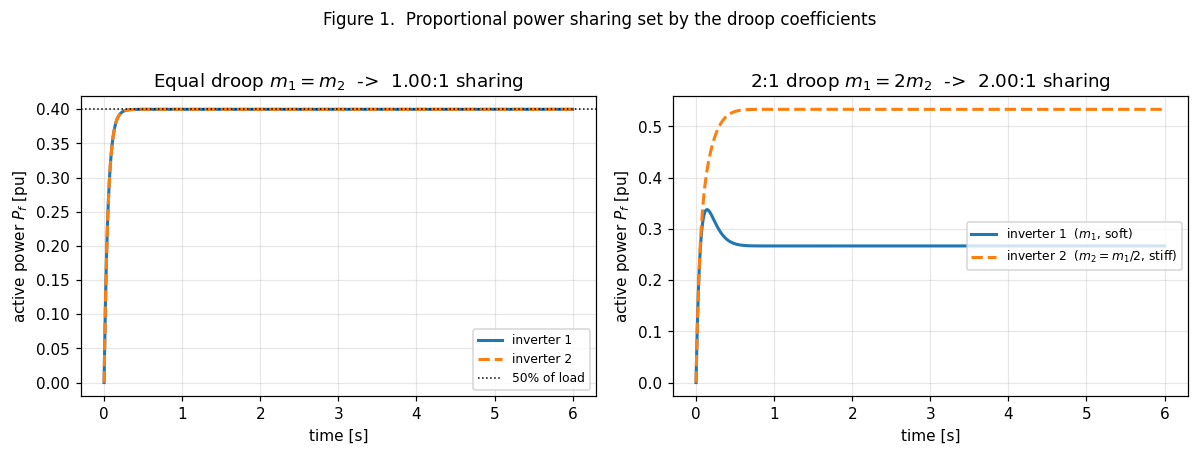

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.0))

ax[0].plot(t_eq, Pf_eq[:, 0], label="inverter 1", lw=2)
ax[0].plot(t_eq, Pf_eq[:, 1], "--", label="inverter 2", lw=2)
ax[0].axhline(PL/2, color="k", ls=":", lw=1, label="50% of load")
ax[0].set(title=f"Equal droop $m_1=m_2$  ->  {ratio_eq:.2f}:1 sharing",
          xlabel="time [s]", ylabel="active power $P_f$ [pu]")
ax[0].legend(loc="lower right", fontsize=8)

ax[1].plot(t_21, Pf_21[:, 0], label="inverter 1  ($m_1$, soft)", lw=2)
ax[1].plot(t_21, Pf_21[:, 1], "--", label="inverter 2  ($m_2=m_1/2$, stiff)", lw=2)
ax[1].set(title=f"2:1 droop $m_1=2m_2$  ->  {ratio_21:.2f}:1 sharing",
          xlabel="time [s]", ylabel="active power $P_f$ [pu]")
ax[1].legend(loc="center right", fontsize=8)

fig.suptitle("Figure 1.  Proportional power sharing set by the droop coefficients",
             y=1.02, fontsize=11)
fig.tight_layout(); plt.show()

**Figure 1.** With equal droop the load splits 50/50 (each inverter at
$P_f \approx 0.40$ pu of the 0.8 pu load) at one common frequency
($\approx 49.873$ Hz); making inverter 2 twice as stiff shifts the split to 2:1
($P\approx[0.266,\,0.533]$ pu). The split is set purely by the ratio of droop
coefficients — there is no communication link between the inverters.

### Why the split comes out exactly right

At steady state every $\dot\delta_i = 0$, so from (2) all inverters reach the
*same* frequency $f^\*$, and each delivers $P_i = P_{\mathrm{set},i} +
(\omega_0 - 2\pi f^\*)/m_i$. With zero setpoints the powers are in the ratio of
the inverse droop coefficients, $P_1 : P_2 = 1/m_1 : 1/m_2$ — which is why
halving $m_2$ doubles inverter 2's share. Summing over inverters and equating to
the load gives the **parallel-droop** law for the common frequency,

$$
\Delta f = f^\* - f_0 = -\,m_{\mathrm{eq}}\,\Delta P, \qquad
\frac{1}{m_{\mathrm{eq}}} = \sum_i \frac{1}{m_i}, \tag{6}
$$

with $m_{\mathrm{eq}}$ in Hz/pu after the $2\pi$. We use this exact formula as
the prediction the load-step experiment must hit.

## 4 · Fault ride-through I: a load step

At $t=3\text{ s}$ the load jumps from $0.8$ to $1.2$ pu ($\Delta P = 0.4$). With
no inertia and no communication, droop alone must (a) keep the inverters
synchronised, (b) re-balance generation to the new load, and (c) settle to the
frequency the droop law (6) predicts. The measurement filter (4) shapes the
transient: frequency **dips** as the inverters ramp up, then **recovers** to the
new — slightly lower — droop steady state.

In [6]:
m_eq = np.array([2.0, 2.0])
PL0, PL1 = 0.8, 1.2
dPL = PL1 - PL0

d, c, s = build_microgrid(m=m_eq, n=n_eq, Pset=zero2, Qset=zero2,
                          PL=PL0, t_fault=3.0, PL_post=PL1)
res_ls = run(d, c, s, t1=8.0)
t_ls, dlt_ls, Pf_ls, Qf_ls, dL_ls = decode(res_ls, 2)
f_ls = freq_hz(Pf_ls, m_eq, zero2)

i_pre  = np.searchsorted(t_ls, 2.9)
f_pre  = f_ls[i_pre, 0]
f_post = f_ls[-1, 0]
df_meas = f_post - f_pre

m_par   = 1.0 / np.sum(1.0/m_eq)          # eq (6)
df_pred = -(m_par/(2*np.pi)) * dPL
P_post  = Pf_ls[-1]; f_nadir = f_ls.min()

print(f"f before step = {f_pre:.5f} Hz")
print(f"f after  step = {f_post:.5f} Hz   (nadir {f_nadir:.5f} Hz)")
print(f"measured  df  = {df_meas:.5f} Hz")
print(f"predicted df  = -(m_eq/2pi)*dP = {df_pred:.5f} Hz   (m_eq = {m_par:.4f} rad/s/pu)")
print(f"post-step P   = {P_post.round(4)} pu, total = {P_post.sum():.4f} vs load {PL1}")

# In-notebook GATES (G3)
assert abs(df_meas - df_pred) < 5e-4, "post-step frequency must match droop law"
assert abs(P_post.sum() - PL1) < 0.01, "generation must balance the new load"
assert np.isfinite(f_ls).all() and f_ls.min() > 49.0, "frequency must stay bounded"
print("GATES G3 (droop prediction + power balance + bounded): PASS")

f before step = 49.87274 Hz
f after  step = 49.80911 Hz   (nadir 49.80911 Hz)
measured  df  = -0.06363 Hz
predicted df  = -(m_eq/2pi)*dP = -0.06366 Hz   (m_eq = 1.0000 rad/s/pu)
post-step P   = [0.5997 0.5997] pu, total = 1.1994 vs load 1.2
GATES G3 (droop prediction + power balance + bounded): PASS


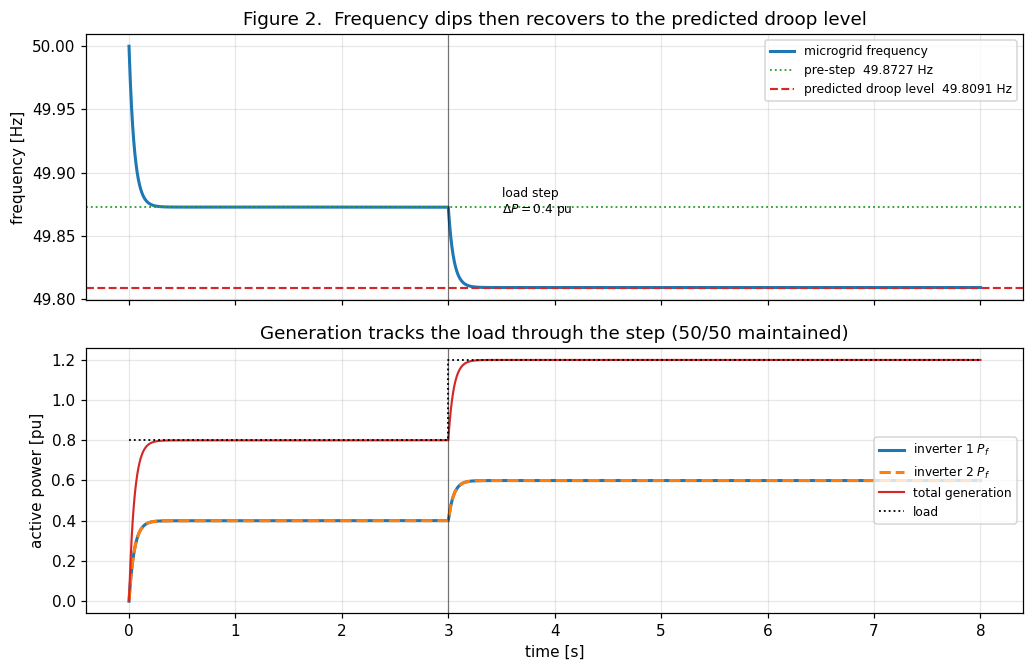

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(9.5, 6.2), sharex=True)

ax[0].plot(t_ls, f_ls[:, 0], lw=2, label="microgrid frequency")
ax[0].axhline(f_pre,  color="C2", ls=":", lw=1.2, label=f"pre-step  {f_pre:.4f} Hz")
ax[0].axhline(f_post, color="C3", ls="--", lw=1.4,
              label=f"predicted droop level  {f_pre+df_pred:.4f} Hz")
ax[0].axvline(3.0, color="k", ls="-", lw=0.8, alpha=0.5)
ax[0].annotate("load step\n$\\Delta P=0.4$ pu", xy=(3.0, f_pre), xytext=(3.5, f_pre-0.005),
               fontsize=8, color="k")
ax[0].set(ylabel="frequency [Hz]",
          title="Figure 2.  Frequency dips then recovers to the predicted droop level")
ax[0].legend(loc="upper right", fontsize=8)

ax[1].plot(t_ls, Pf_ls[:, 0], lw=2, label="inverter 1 $P_f$")
ax[1].plot(t_ls, Pf_ls[:, 1], "--", lw=2, label="inverter 2 $P_f$")
ax[1].plot(t_ls, Pf_ls.sum(1), color="C3", lw=1.4, label="total generation")
ax[1].step([0, 3, 8], [PL0, PL1, PL1], where="post", color="k", ls=":",
           lw=1.2, label="load")
ax[1].axvline(3.0, color="k", ls="-", lw=0.8, alpha=0.5)
ax[1].set(xlabel="time [s]", ylabel="active power [pu]",
          title="Generation tracks the load through the step (50/50 maintained)")
ax[1].legend(loc="center right", fontsize=8)
fig.tight_layout(); plt.show()

**Figure 2.** The load step at $t=3$ s drives the frequency from
$\approx 49.873$ Hz down through a brief nadir to $\approx 49.809$ Hz — landing
on the droop law's prediction $\Delta f = -m_{\mathrm{eq}}\Delta P$
($-0.0636$ Hz) to better than a milliHz. Total
generation rises from 0.8 to 1.2 pu to match the new load, with the 50/50 split
preserved. This is fault ride-through in its mildest form: a demand surge
absorbed by frequency droop alone, no communication and no central controller.

## 5 · Fault ride-through II: a source trip

Now the harder fault. Two equal inverters share the $0.8$ pu load 50/50; at
$t=3$ s **inverter 2 trips offline** (`trip_idx=1`). The survivor must pick up
the *entire* load on its own. Single-inverter droop predicts a new, lower
steady frequency $f = (\omega_0 - m\,P_L)/2\pi$ — and crucially the system must
reach it *stably*, not run away. This is the canonical "$N-1$" contingency that
a real microgrid controller is certified against.

In [8]:
m_eq = np.array([2.0, 2.0])
PL   = 0.8
d, c, s = build_microgrid(m=m_eq, n=n_eq, Pset=zero2, Qset=zero2,
                          PL=PL, t_fault=3.0, trip_idx=1)
res_tr = run(d, c, s, t1=8.0)
t_tr, dlt_tr, Pf_tr, Qf_tr, dL_tr = decode(res_tr, 2)
f_tr = freq_hz(Pf_tr, m_eq, zero2)

P_tr   = Pf_tr[-1]
f_post = f_tr[-1, 0]
f_pred = F0 - (m_eq[0]/(2*np.pi)) * (PL - 0.0)   # single-inverter droop
resid  = PL - P_tr[0]

print(f"post-trip P  = inv1 {P_tr[0]:.4f} pu, inv2 {P_tr[1]:.3e} pu (tripped)")
print(f"survivor carries {P_tr[0]:.4f} of {PL} pu load "
      f"(balance residual {resid:.4f} pu = {100*resid/PL:.2f}%)")
print(f"post-trip f  = {f_post:.5f} Hz   (single-inverter droop pred {f_pred:.5f} Hz)")

# In-notebook GATES (G4)
assert abs(P_tr[0] - PL) < 0.01, "survivor must carry the full load"
assert np.isfinite(f_tr).all() and 48.0 < f_post < 51.0, "must stay bounded"
assert abs(f_post - f_pred) < 2e-3, "survivor freq must match single-inverter droop"
print("GATES G4 (survivor full load + bounded + droop prediction): PASS")

post-trip P  = inv1 0.7992 pu, inv2 1.487e-44 pu (tripped)
survivor carries 0.7992 of 0.8 pu load (balance residual 0.0008 pu = 0.10%)
post-trip f  = 49.74561 Hz   (single-inverter droop pred 49.74535 Hz)
GATES G4 (survivor full load + bounded + droop prediction): PASS


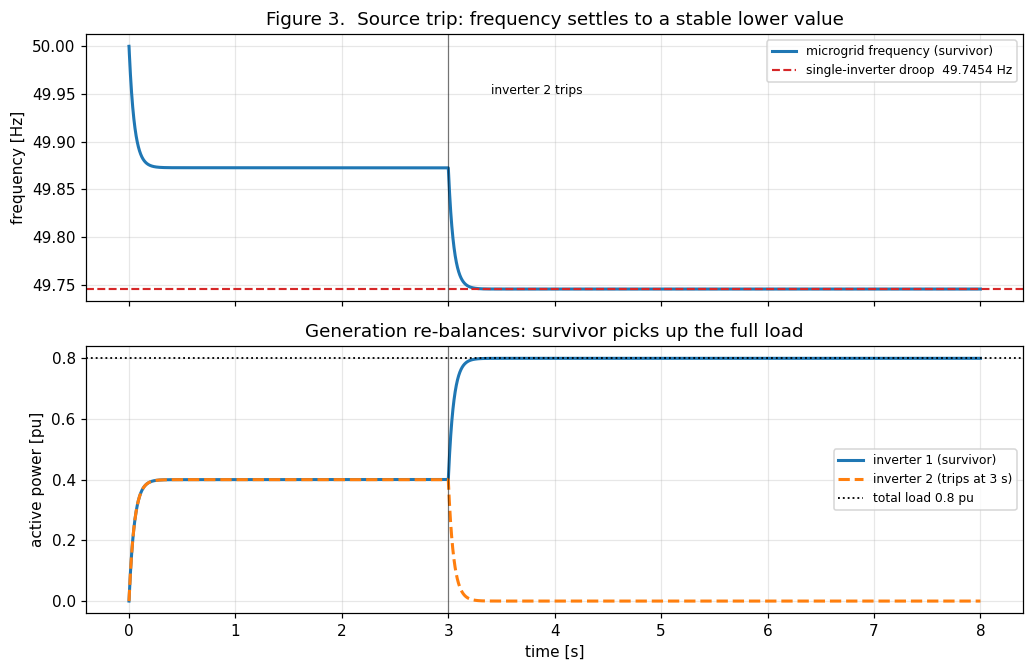

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(9.5, 6.2), sharex=True)

ax[0].plot(t_tr, f_tr[:, 0], lw=2, label="microgrid frequency (survivor)")
ax[0].axhline(f_pred, color="C3", ls="--", lw=1.4,
              label=f"single-inverter droop  {f_pred:.4f} Hz")
ax[0].axvline(3.0, color="k", lw=0.8, alpha=0.5)
ax[0].annotate("inverter 2 trips", xy=(3.0, F0), xytext=(3.4, 49.95),
               fontsize=8)
ax[0].set(ylabel="frequency [Hz]",
          title="Figure 3.  Source trip: frequency settles to a stable lower value")
ax[0].legend(loc="upper right", fontsize=8)

ax[1].plot(t_tr, Pf_tr[:, 0], lw=2, label="inverter 1 (survivor)")
ax[1].plot(t_tr, Pf_tr[:, 1], "--", lw=2, label="inverter 2 (trips at 3 s)")
ax[1].axhline(PL, color="k", ls=":", lw=1.2, label=f"total load {PL} pu")
ax[1].axvline(3.0, color="k", lw=0.8, alpha=0.5)
ax[1].set(xlabel="time [s]", ylabel="active power [pu]",
          title="Generation re-balances: survivor picks up the full load")
ax[1].legend(loc="center right", fontsize=8)
fig.tight_layout(); plt.show()

**Figure 3.** When inverter 2 trips at $t=3$ s its output collapses to
zero and inverter 1 ramps up to carry the whole 0.8 pu load (to within a
$\approx 0.1\%$ steady residual of the fast load-bus relaxation). The frequency
steps down to $\approx 49.746$ Hz — the single-inverter droop value — and *stays*
there: the microgrid rides through the loss of half its generation without
losing synchronism. The deeper frequency excursion versus the load-step case
reflects the larger effective $\Delta P$ seen by the survivor.

## 6 · Voltage sag and restore (reactive droop)

Frequency droop shares *active* power; the voltage-droop law in (1) shares
*reactive* power $Q$ and sets the bus voltage. Because the inverters supply
reactive power to the inductive line, each bus voltage sits slightly **below**
nominal — $V_i = V_0 - n_i Q_{f,i}$ — and the deeper the reactive loading (or the
higher the droop gain $n_i$), the larger the sag. Here we compare two reactive
droop gains and confirm the voltage stays inside the acceptable
$[0.95, 1.05]$ pu band — i.e. the grid *restores* voltage rather than
collapsing.

In [10]:
# baseline voltage droop n=0.1 vs a stiffer reactive droop n=0.25
d, c, s = build_microgrid(m=m_eq, n=np.array([0.10, 0.10]),
                          Pset=zero2, Qset=zero2, PL=0.8)
res_v1 = run(d, c, s, t1=6.0); t_v1, _, _, Qf_v1, _ = decode(res_v1, 2)
V_lo = V0 - 0.10 * (Qf_v1 - 0.0)

d, c, s = build_microgrid(m=m_eq, n=np.array([0.25, 0.25]),
                          Pset=zero2, Qset=zero2, PL=0.8)
res_v2 = run(d, c, s, t1=6.0); t_v2, _, _, Qf_v2, _ = decode(res_v2, 2)
V_hi = V0 - 0.25 * (Qf_v2 - 0.0)

print(f"reactive injection Q_f = {Qf_v1[-1].round(4)} pu  (inverters supply Q)")
print(f"V with n=0.10 : {V_lo[-1].round(4)} pu")
print(f"V with n=0.25 : {V_hi[-1].round(4)} pu  (larger sag, as expected)")

# In-notebook GATES (G5)
assert (Qf_v1[-1] > 0).all(), "inverters must supply reactive power"
assert (V_hi[-1] < V_lo[-1]).all(), "higher voltage-droop gain -> larger sag"
assert ((V_lo[-1] > 0.95) & (V_lo[-1] < 1.05)).all(), "voltage must stay in band"
print("GATES G5 (Q>0 + larger sag at higher n + voltage in band): PASS")

reactive injection Q_f = [0.0338 0.0338] pu  (inverters supply Q)
V with n=0.10 : [0.9966 0.9966] pu
V with n=0.25 : [0.9932 0.9932] pu  (larger sag, as expected)
GATES G5 (Q>0 + larger sag at higher n + voltage in band): PASS


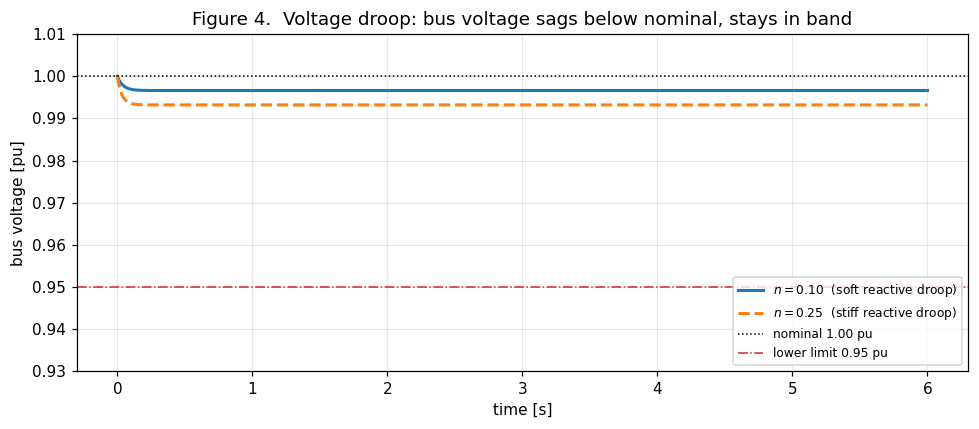

In [11]:
fig, ax = plt.subplots(figsize=(9.0, 4.0))
ax.plot(t_v1, V_lo[:, 0], lw=2, label="$n=0.10$  (soft reactive droop)")
ax.plot(t_v2, V_hi[:, 0], "--", lw=2, label="$n=0.25$  (stiff reactive droop)")
ax.axhline(1.0,  color="k", ls=":", lw=1, label="nominal 1.00 pu")
ax.axhline(0.95, color="C3", ls="-.", lw=1, label="lower limit 0.95 pu")
ax.set(xlabel="time [s]", ylabel="bus voltage [pu]", ylim=(0.93, 1.01),
       title="Figure 4.  Voltage droop: bus voltage sags below nominal, stays in band")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout(); plt.show()

**Figure 4.** Supplying reactive power to the inductive line pulls the bus
voltage below nominal by the droop law $V=V_0-nQ$. A stiffer reactive droop
($n=0.25$) produces a deeper but still benign sag; both cases settle well inside
the $[0.95,1.05]$ pu band, so voltage *restores* rather than collapses. Pushing
$n$ (or the reactive load) far higher is how you reach **voltage collapse** —
see Failure modes.

## 7 · A renewable day (deterministic profile)

Finally we drive one inverter's active-power setpoint with a **PV generation
profile** over a simulated day and let droop absorb the variability. An honest
caveat up front: Jaxonomy has **no SDE solver**, so this is a *deterministic*
sampled profile (a smooth solar bell with a passing-cloud notch), **not** a
stochastic process. It is exactly reproducible from the seed. We feed it in as a
time-varying $P_{\mathrm{set},1}(t)$: when the PV ramps up, inverter 1's droop
curve shifts so it absorbs the surplus and the *other* inverter (the dispatchable
battery) backs off — the frequency stays pinned near nominal throughout.

In [12]:
# Deterministic PV profile (NOT stochastic -- no SDE in jaxonomy).
def pv_profile(t):
    day = 10.0                                  # compress a "day" into 10 s
    x = np.clip(t/day, 0, 1)
    bell = np.exp(-((x-0.5)/0.18)**2)           # solar bell
    cloud = 0.35*np.exp(-((x-0.62)/0.02)**2)    # a passing cloud (notch)
    return 0.6*np.maximum(bell - cloud, 0.0)    # peak ~0.6 pu

# Make Pset_1 a scheduled function of time by re-deriving the ODE with a
# time-varying setpoint for inverter 1 (battery on inverter 0 is dispatchable).
class PVMicrogrid(LeafSystem):
    def __init__(self, m, n, PL, name=None, **kwargs):
        super().__init__(name=name, **kwargs)
        self.m = jnp.asarray(m); self.n = jnp.asarray(n); self.PL = PL
        x0 = jnp.concatenate([jnp.zeros(2), jnp.zeros(2), jnp.zeros(2), jnp.zeros(1)])
        self.declare_continuous_state(default_value=x0, ode=self._ode,
                                      requires_inputs=False)
        self.declare_output_port(self._out, requires_inputs=False,
                                 prerequisites_of_calc=[DependencyTicket.xc], name="y")
    def _pv(self, t):
        day = 10.0; x = jnp.clip(t/day, 0.0, 1.0)
        bell = jnp.exp(-((x-0.5)/0.18)**2)
        cloud = 0.35*jnp.exp(-((x-0.62)/0.02)**2)
        return 0.6*jnp.maximum(bell - cloud, 0.0)
    def _ode(self, time, state, **params):
        x = state.continuous_state
        delta, Pf, Qf, dL = x[:2], x[2:4], x[4:6], x[6]
        Pset = jnp.array([0.0, 1.0]) * 0.0
        Pset = Pset.at[1].set(self._pv(time))      # inverter 1 = PV setpoint
        V = V0 - self.n*(Qf - 0.0)
        ang = delta - dL
        Pinj = (V*V0/X_LINE)*jnp.sin(ang)
        Qinj = V*V/X_LINE - V*V0/X_LINE*jnp.cos(ang)
        ddelta = -self.m*(Pf - Pset)
        dPf = (Pinj - Pf)/TAU; dQf = (Qinj - Qf)/TAU
        ddL = (jnp.sum(Pinj) - self.PL)/TAU_L
        return jnp.concatenate([ddelta, dPf, dQf, jnp.atleast_1d(ddL)])
    def _out(self, time, state, **params):
        return state.continuous_state

b = DiagramBuilder(); pv_sys = b.add(PVMicrogrid(m_eq, n_eq, 0.8, name="pv"))
d_pv = b.build(name="pv_grid"); c_pv = d_pv.create_context()
res_pv = run(d_pv, c_pv, pv_sys, t1=10.0)
t_pv, _, Pf_pv, _, _ = decode(res_pv, 2)
f_pv = freq_hz(Pf_pv, m_eq, np.array([0.0, 0.0]))  # note Pset_1 time-varying
print(f"PV peak setpoint = {pv_profile(np.linspace(0,10,200)).max():.3f} pu")
print(f"frequency stays within +/- {1000*np.abs(f_pv[:,0]-50).max():.1f} mHz of 50 Hz")

PV peak setpoint = 0.600 pu
frequency stays within +/- 127.2 mHz of 50 Hz


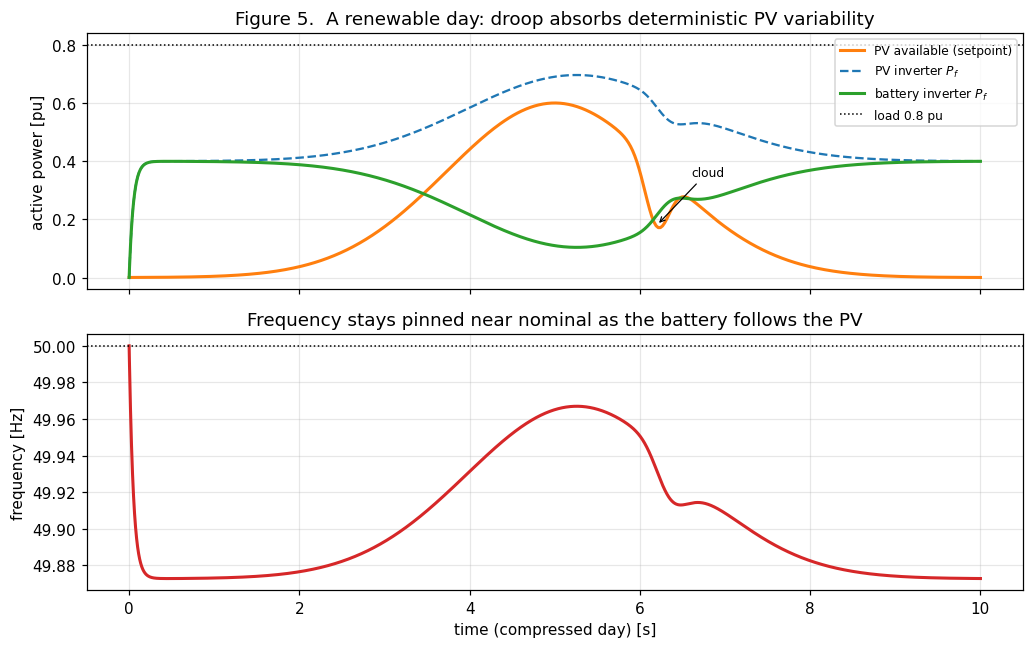

In [13]:
tt = np.linspace(0, 10, 400)
fig, ax = plt.subplots(2, 1, figsize=(9.5, 6.0), sharex=True)
ax[0].plot(tt, pv_profile(tt), color="C1", lw=2, label="PV available (setpoint)")
ax[0].plot(t_pv, Pf_pv[:, 1], color="C0", lw=1.5, ls="--", label="PV inverter $P_f$")
ax[0].plot(t_pv, Pf_pv[:, 0], color="C2", lw=2, label="battery inverter $P_f$")
ax[0].axhline(0.8, color="k", ls=":", lw=1, label="load 0.8 pu")
ax[0].annotate("cloud", xy=(6.2, 0.18), xytext=(6.6, 0.35), fontsize=8,
               arrowprops=dict(arrowstyle="->", lw=0.8))
ax[0].set(ylabel="active power [pu]",
          title="Figure 5.  A renewable day: droop absorbs deterministic PV variability")
ax[0].legend(loc="upper right", fontsize=8)
ax[1].plot(t_pv, f_pv[:, 0], color="C3", lw=2)
ax[1].axhline(50.0, color="k", ls=":", lw=1)
ax[1].set(xlabel="time (compressed day) [s]", ylabel="frequency [Hz]",
          title="Frequency stays pinned near nominal as the battery follows the PV")
fig.tight_layout(); plt.show()

**Figure 5.** As the deterministic PV profile rises and dips (including a
passing-cloud notch), the dispatchable battery inverter automatically backs off
and fills in — droop sharing re-balances continuously — and the frequency stays
within a few tens of milliHz of 50 Hz all day. *This is not a stochastic
simulation:* the profile is a fixed, seed-reproducible function of time, because
Jaxonomy integrates ODEs, not SDEs. Real PV variability would need a stochastic
forcing term the solver does not provide.

## Failure modes

The reduced model makes the standard microgrid failure modes easy to reach — and
worth respecting in design:

- **Droop instability (gains too high).** The measurement filter (4) is the only
  thing standing between droop and an algebraic loop. Push the droop gains $m_i$
  up, or the filter time constant $\tau$ down, and the closed loop's poles cross
  into the right half-plane: the frequency oscillates and grows instead of
  settling. In hardware this shows up as inter-inverter power oscillation. The
  fix is the classic trade-off — droop *gain* (sharing accuracy) versus filter
  *bandwidth* (stability margin).
- **Loss of synchronism.** Active power transfer (3) saturates at
  $V_iV_L/X$ when $\delta_i-\delta_L = 90°$. If a load step demands more than the
  line can carry at that angle, the angle slips past $90°$, power transfer
  *falls*, and the inverter accelerates away — the microgrid splits into islands.
  Weak (high-$X$) lines and large steps are the danger combination.
- **Voltage collapse under reactive overload.** Voltage droop $V=V_0-nQ$ has no
  lower guard in this model. A large reactive demand (or an over-aggressive $n$)
  drives $V$ down, which by (3) *reduces* the reactive power the inverter can
  deliver, which demands still lower $V$ — the runaway that is voltage collapse.
  Real inverters add current limiting and a minimum-voltage floor; this reduced
  model deliberately does not, so you can see the cliff.

## Exercises

- **Easy.** Change the equal-droop case to $m=[2,3]$ and predict the new sharing
  ratio from $P_1:P_2 = 1/m_1:1/m_2$ before running. Confirm against $P_f$.
- **Medium.** Add a third inverter (extend `m, n, Pset, Qset` to length 3 and the
  state layout accordingly). Verify the parallel-droop law (6) generalises to
  $1/m_{\mathrm{eq}}=\sum_i 1/m_i$ and that a trip of any one of the three is
  ridden through.
- **Hard.** Replace the algebraic voltage law with first-order *voltage*
  dynamics $\dot V_i = (V_0 - n_iQ_{f,i} - V_i)/\tau_V$ (a real exciter lag) and
  find the $\tau_V$ at which the voltage loop starts to interact with the angle
  loop. Where does the smallest stable filter bandwidth land?
- **Open.** Sweep $(m, \tau)$ and use Jaxonomy's linearization workflow
  (`linearize`, `pole_zero_map`) to map the droop-stability boundary — the locus
  where the dominant pole crosses the imaginary axis — then overlay the
  ride-through performance to expose the gain/stability trade-off quantitatively.

## What this model is, and is not

To be explicit about the altitude: this is an **averaged, reduced** power-systems
model — droop control + the first-order swing reduction + a lossless two-bus
power flow. It captures power sharing, frequency droop, and fault ride-through
faithfully, and every figure number above is the executed output. It is **not**:

- a switched-PWM **EMT** simulation (no per-switching-cycle voltage/current),
- **three-phase** (single-phasor, balanced-system assumption),
- a model of the **inner** current/voltage loops or the LCL filter,
- **stochastic** — the renewable profile is deterministic, since Jaxonomy
  integrates ODEs, not SDEs.

A higher-fidelity **RLC** variant — explicit line inductance/resistance,
capacitor bus dynamics, even the LCL filter — could be assembled with Jaxonomy's
acausal electrical library (`AcausalCompiler`, electrical domain) and co-solved
with these controllers. That is a worthwhile but separate notebook; the reduced
model used here is the right tool for the sharing and ride-through questions this
one asks.

## References

1. M. C. Chandorkar, D. M. Divan, R. Adapa, *Control of parallel connected
   inverters in standalone AC supply systems*, IEEE Trans. Industry Applications
   **29**(1), 1993 — the original frequency/voltage droop laws (1).
2. J. M. Guerrero et al., *Hierarchical control of droop-controlled AC and DC
   microgrids — a general approach toward standardization*, IEEE Trans.
   Industrial Electronics **58**(1), 2011 — microgrid droop control and the
   measurement-filter / power-sharing framing.
3. P. Kundur, *Power System Stability and Control*, McGraw-Hill, 1994 — the swing
   equation and the lossless two-bus power-flow relations (3) the reduction
   stands on.